<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L07-Modelos_ARIMA%20/notebooks/L07_2_Simulaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # para gráficos en enrejados irregulares
import statsmodels.graphics.tsaplots as smt # para gráficos ACF y PACF
from statsmodels.tsa.arima_process import arma_generate_sample # para simulación ARIMA

np.random.seed(10) # para reproducibilidad de simulaciones

# **Modelo ARI**

In [2]:
# Definiendo los parámetros para un modelo AR(4)
# El polinomio AR es 1 - ar1*B - ar2*B^2 - ar3*B^3 - ar4*B^4
# Entonces, los coeficientes para generar la simulación deben ser [1, -ar1, -ar2, -ar3, -ar4]
# En este ejemplo ar1 = ar2 = ar3 = ar4 = 0.2
# Los coeficientes AR en esta función se colocan con el signo contrario (por la estructura del polinomio)
ar_coef = [1, -0.2, -0.2, -0.2, -0.2]

# El coeficiente de la parte MA se coloca en 1 por el lag-0 de la serie de ruido incluida en el modelo
ma_coef = [1]

# Generar la serie AR(4) subyacente (sin differenciación todavía)
# Usamos un intercepto para el proceso AR
# Si el usuario quiere un intercepto para la serie ARIMA final, este valor puede ajustarse o eliminarse y aplicar un offset después de cumsum.
# Para ARIMA(p,d,q), arma_generate_sample genera la serie estacionaria (AR part).
ari_sim_diff = arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

# Integrar la serie una vez (d=1) para obtener el ARIMA(4,1,0)
# Esto se hace con una suma acumulativa (np.cumsum)
# La serie integrada necesita un punto de partida; aquí, asumimos que el valor inicial es 0 para la serie diferenciada,
# y la serie integrada comienza acumulando desde allí.
ari_sim = np.cumsum(ari_sim_diff)

print("Primeros 10 valores de la serie ARIMA(4,1,0) simulada:")
print(ari_sim[:10])

Primeros 10 valores de la serie ARIMA(4,1,0) simulada:
[1.3315865  2.31318278 1.23041904 1.468119   2.38307878 1.87329167
 2.05082503 2.32345476 2.49881334 2.34736004]


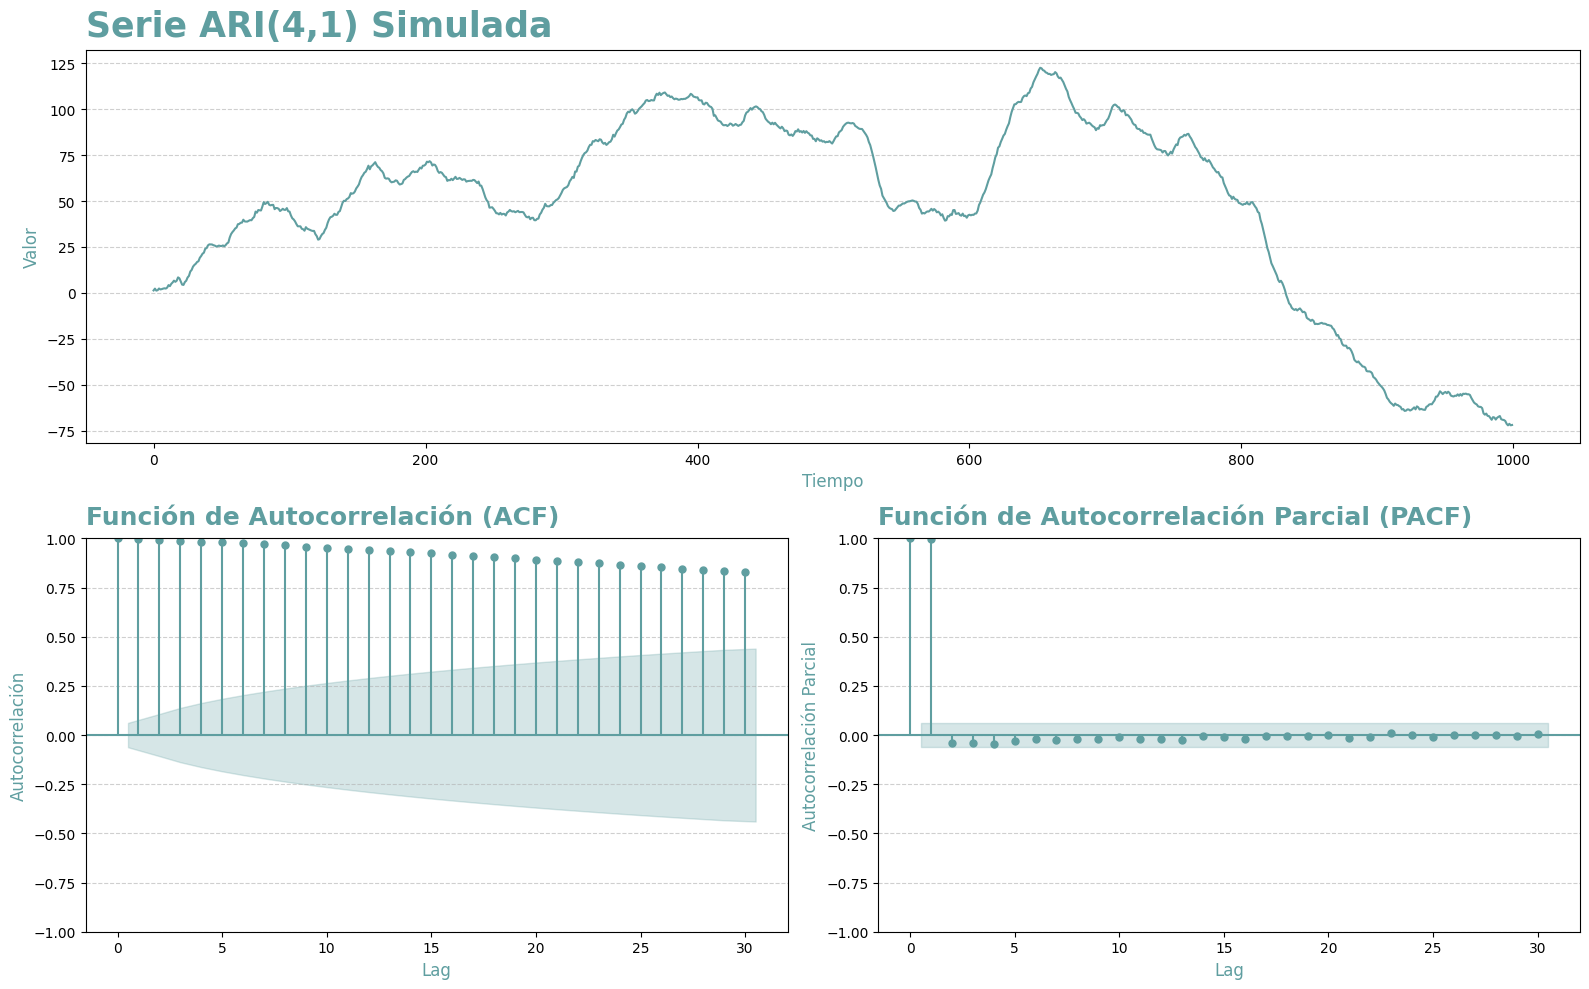

In [3]:
# Gráfico de Simulaciones
serie = ari_sim
nombre = 'ARI(4,1) Simulada'
graphColor = 'cadetblue'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

# **Modelo IMA**

In [4]:
# Definiendo los parámetros para un modelo MA(4)
# Los coeficientes MA se colocan con el signo contrario al del polinomio MA (para arma_generate_sample)
# El polinomio MA es 1 + ma1*B + ma2*B^2 + ma3*B^3 + ma4*B^4
# Entonces, los coeficientes para generar la simulación deben ser [1, ma1, ma2, ma3, ma4]
# En este ejemplo ma1 = ma2 = ma3 = ma4 = 0.2
# Para un modelo MA puro, el coeficiente AR es simplemente [1]
ar_coef = [1]

# Los coeficientes MA se colocan directamente, incluyendo el lag-0
ma_coef = [1, 0.2, 0.2, 0.2, 0.2]

# Generar la serie MA(4) subyacente (sin differenciación todavía)
# Para ARIMA(p,d,q), arma_generate_sample genera la serie estacionaria (la parte ARMA).
ima_sim_diff = arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

# Integrar la serie una vez (d=1) para obtener el ARIMA(0,1,4)
# Esto se hace con una suma acumulativa (np.cumsum)
# La serie integrada necesita un punto de partida; aquí, asumimos que el valor inicial es 0 para la serie diferenciada,
# y la serie integrada comienza acumulando desde allí.
ima_sim = np.cumsum(ima_sim_diff)

print("Primeros 10 valores de la serie ARIMA(0,1,4) simulada:")
print(ima_sim[:10])

Primeros 10 valores de la serie ARIMA(0,1,4) simulada:
[1.51325223 1.67356908 1.80833285 3.23014013 4.89533039 5.99424625
 5.35978942 6.2568687  6.73902647 7.04007105]


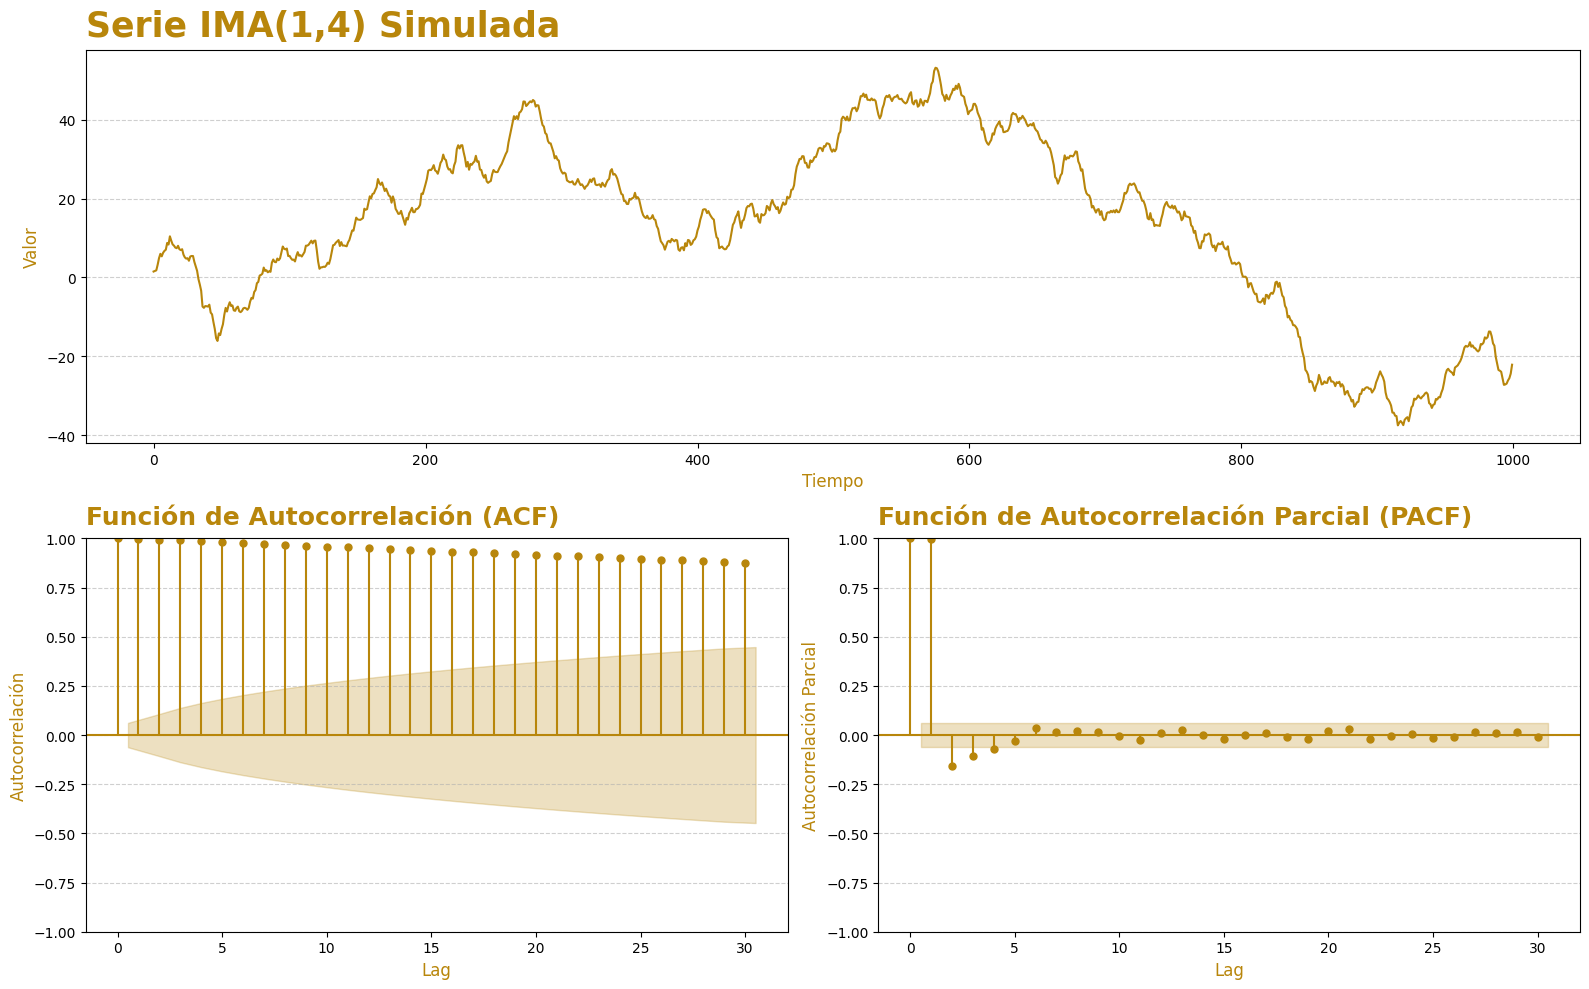

In [5]:
# Gráfico de Simulaciones
serie = ima_sim
nombre = 'IMA(1,4) Simulada'
graphColor = 'darkgoldenrod'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

# **Modelo ARIMA**

In [6]:
# Definiendo los parámetros para un modelo ARMA(4,4) que será integrado (ARIMA(4,1,4))
# El polinomio AR es 1 - ar1*B - ar2*B^2 - ar3*B^3 - ar4*B^4
# Entonces, los coeficientes AR para generar la simulación deben ser [1, -ar1, -ar2, -ar3, -ar4]
# En este ejemplo ar1 = ar2 = ar3 = ar4 = 0.2
ar_coef = [1, -0.2, -0.2, -0.2, -0.2]

# Los coeficientes MA se colocan directamente, incluyendo el lag-0
# El polinomio MA es 1 + ma1*B + ma2*B^2 + ma3*B^3 + ma4*B^4
# Entonces, los coeficientes MA para generar la simulación deben ser [1, ma1, ma2, ma3, ma4]
# En este ejemplo ma1 = ma2 = ma3 = ma4 = 0.2
ma_coef = [1, 0.2, 0.2, 0.2, 0.2]

# Generar la serie ARMA(4,4) subyacente (sin differenciación todavía)
# Para ARIMA(p,d,q), arma_generate_sample genera la serie estacionaria (la parte ARMA).
arima_sim_diff = arma_generate_sample(
    ar=ar_coef, ma=ma_coef, nsample=1000
)

# Integrar la serie una vez (d=1) para obtener el ARIMA(4,1,4)
# Esto se hace con una suma acumulativa (np.cumsum)
# La serie integrada necesita un punto de partida; aquí, asumimos que el valor inicial es 0 para la serie diferenciada,
# y la serie integrada comienza acumulando desde allí.
arima_sim = np.cumsum(arima_sim_diff)

print("Primeros 10 valores de la serie ARIMA(4,1,4) simulada:")
print(arima_sim[:10])

Primeros 10 valores de la serie ARIMA(0,1,4) simulada:
[1.51325223 1.67356908 1.80833285 3.23014013 4.89533039 5.99424625
 5.35978942 6.2568687  6.73902647 7.04007105]


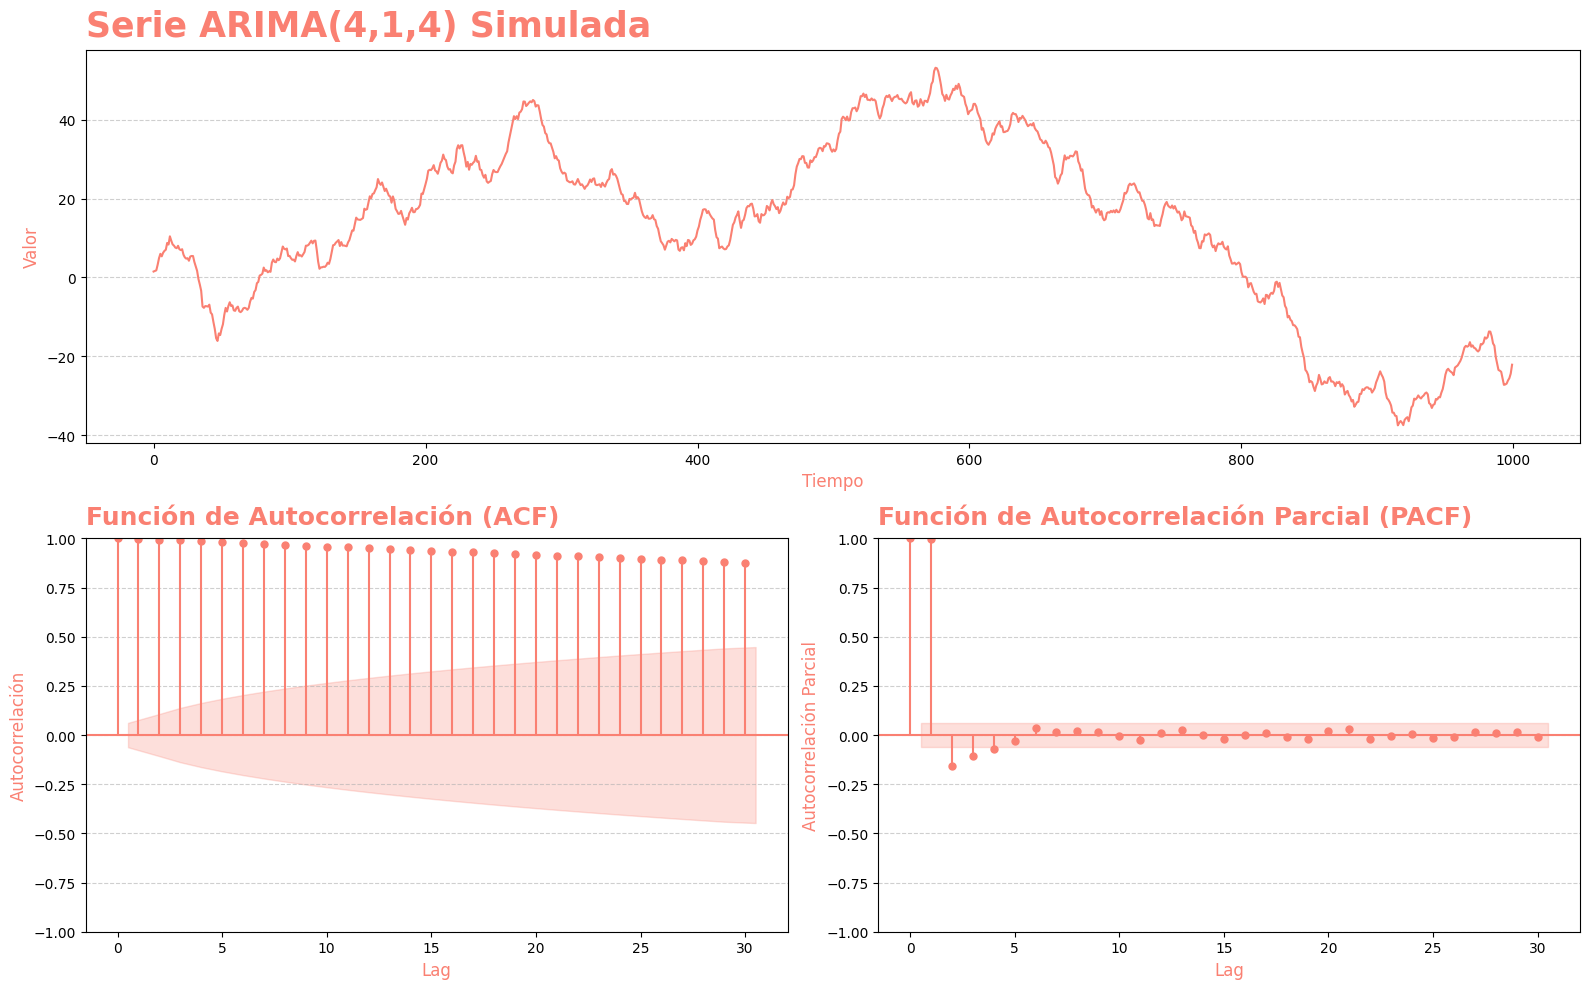

In [7]:
# Gráfico de Simulaciones
serie = arima_sim
nombre = 'ARIMA(4,1,4) Simulada'
graphColor = 'salmon'

# Crear la figura y el GridSpec para el layout de 2x2
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Subplot para la serie simulada (ocupa toda la fila superior)
ax0 = fig.add_subplot(gs[0, :]) # gs[0, :] indica la primera fila, todas las columnas
ax0.plot(serie, color = graphColor)
ax0.set_title('Serie ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Tiempo', fontsize=12, color = graphColor,)
ax0.set_ylabel('Valor', fontsize=12, color = graphColor,)
ax0.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la ACF (parte inferior izquierda)
ax1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] indica la segunda fila, primera columna
smt.plot_acf(serie, lags=30, ax=ax1, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y formato
ax1.set_title('Función de Autocorrelación (ACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax1.set_ylabel('Autocorrelación', fontsize=12, color = graphColor)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Subplot para la PACF (parte inferior derecha)
ax2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] indica la segunda fila, segunda columna
smt.plot_pacf(serie, lags=30, ax=ax2, title='', color = graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
# Etiquetas y Formato
ax2.set_title('Función de Autocorrelación Parcial (PACF)', loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', fontsize=12, color = graphColor,)
ax2.set_ylabel('Autocorrelación Parcial', fontsize=12, color = graphColor)
ax2.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout() # Ajustar el layout para evitar empalme
plt.show()

## **Comparativo**

/tmp/ipykernel_7373/36056920.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


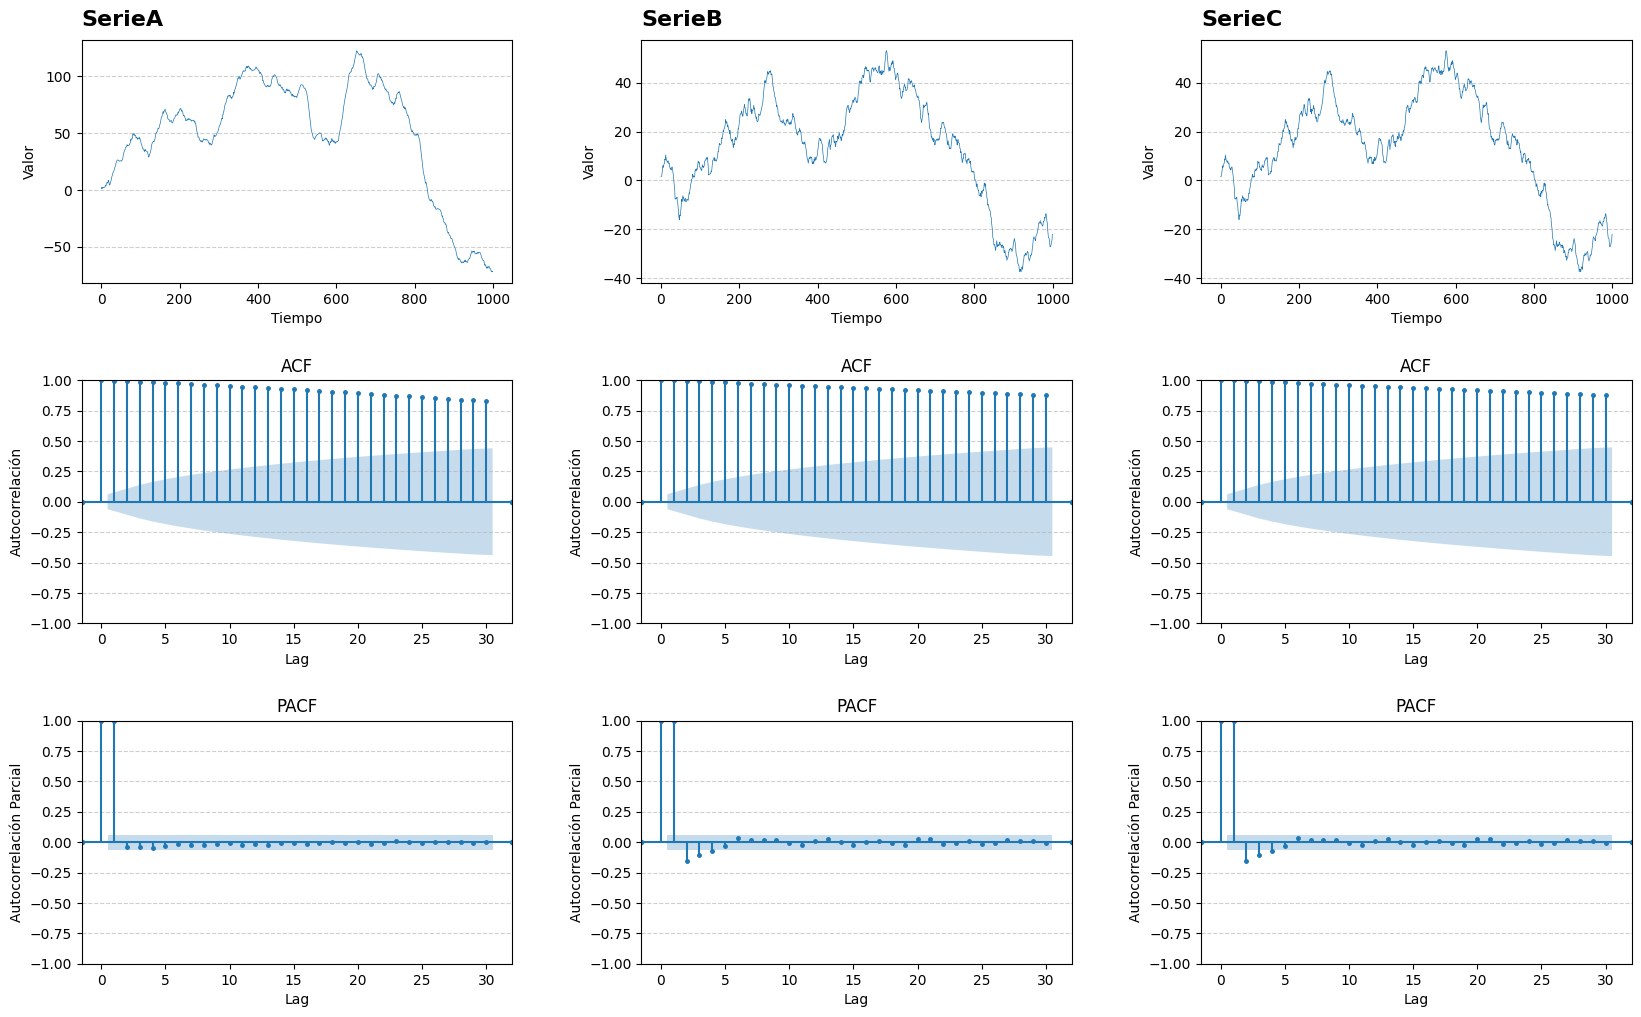

In [8]:
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)


modelos = {
    'SerieA': ari_sim,
    'SerieB': ima_sim,
    'SerieC': arima_sim
}

# Row 0: Simulated Series
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(datos, lw = 0.5)
    ax.set_title(nombre, loc='left', fontweight='bold', size=16, pad=10)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Row 1: ACF Plots
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[1, i])
    smt.plot_acf(datos, lags=30, ax=ax, title='ACF', marker = '.')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelación')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Row 2: PACF Plots
for i, (nombre, datos) in enumerate(modelos.items()):
    ax = fig.add_subplot(gs[2, i])
    smt.plot_pacf(datos, lags=30, ax=ax, title='PACF', marker = '.')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelación Parcial')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()